In [157]:
# Data manipulation
import pandas as pd
import numpy as np

# Modelling
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Visualisation
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
import seaborn as sns

## 1. Exploratory Data Analysis

We analyse the **Student Performance Factors** dataset, covering variable structure, missing data, and relationships with the target variable `Exam_Score`. Two analytical tracks are derived based on the missing data findings:

- **Track A (Imputed):** All rows are retained; missing values in three categorical columns are filled by training-set mode imputation.
- **Track B (Dropped):** Rows with any missing values are removed via listwise deletion.

### 1.1 Data Loading

In [158]:
df = pd.read_csv("../data/StudentPerformanceFactors.csv")

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("Features List:")
print(*df.columns, sep=", ")

Dataset Shape: 6607 rows, 20 columns
Features List:
Hours_Studied, Attendance, Parental_Involvement, Access_to_Resources, Extracurricular_Activities, Sleep_Hours, Previous_Scores, Motivation_Level, Internet_Access, Tutoring_Sessions, Family_Income, Teacher_Quality, School_Type, Peer_Influence, Physical_Activity, Learning_Disabilities, Parental_Education_Level, Distance_from_Home, Gender, Exam_Score


### 1.2 Data Validation and Cleaning

Before addressing missing values, a data integrity check identifies logically impossible entries — such as numerical scores outside their valid range or negative values — and verifies that all categorical variables contain recognised labels. This guards against data-entry errors that would otherwise bias subsequent regression estimates.

In [159]:
# Check: Numerical attributes invalid entries
audit_results = {
    "Exam_Score > 100": len(df[df['Exam_Score'] > 100]),
    "Attendance > 100%": len(df[df['Attendance'] > 100]),
    "Previous_Scores > 100": len(df[df['Previous_Scores'] > 100]),
    "Sleep_Hours > 24": len(df[df['Sleep_Hours'] > 24]),
    "Any Negative Values": (df.select_dtypes(include=[np.number]) < 0).sum().sum()
}

for issue, count in audit_results.items():
    print(f"{issue}: {count}")

Exam_Score > 100: 1
Attendance > 100%: 0
Previous_Scores > 100: 0
Sleep_Hours > 24: 0
Any Negative Values: 0


In [160]:
# Check: categorical attributes invalid entries
cat_cols = df.select_dtypes(include=['object']).columns

cat_summary = []
for col in cat_cols:
    unique_vals = df[col].dropna().unique()
    cat_summary.append({
        "Attribute": col,
        "Unique Values": ", ".join(map(str, unique_vals)),
        "Count": len(unique_vals)
    })

display(pd.DataFrame(cat_summary))

,Attribute,Unique Values,Count
0,Parental_Involvement,"Low, Medium, High",3
1,Access_to_Resources,"High, Medium, Low",3
2,Extracurricular_Activities,"No, Yes",2
3,Motivation_Level,"Low, Medium, High",3
4,Internet_Access,"Yes, No",2
5,Family_Income,"Low, Medium, High",3
6,Teacher_Quality,"Medium, High, Low",3
7,School_Type,"Public, Private",2
8,Peer_Influence,"Positive, Negative, Neutral",3
9,Learning_Disabilities,"No, Yes",2


In [161]:
# Remove impossible scores (only the row with score 101)
df = df[df["Exam_Score"] <= 100].copy()

The check identified one anomalous observation (`Exam_Score` = 101), which exceeds the theoretical maximum and was removed. All other numerical predictors lie within plausible academic and physical ranges.

Categorical validation confirms that all nominal and ordinal variables contain recognised labels. With at most three distinct levels per feature ($n \le 3$), one-hot encoding produces a compact and well-defined set of binary indicators.

#### 1.2.1 Missing Data Strategy

In [162]:
missing = df.isna().sum()
missing_table = pd.DataFrame({
    "Dtype": df.dtypes,
    "Count": missing,
    "Proportion": (missing / len(df)).round(4),
    "Percentage (%)": (missing / len(df) * 100).round(2)
}).sort_values("Count", ascending=False)

# Display only rows with missing values
display(missing_table[missing_table["Count"] > 0])

,Dtype,Count,Proportion,Percentage (%)
Parental_Education_Level,object,90,0.0136,1.36
Teacher_Quality,object,78,0.0118,1.18
Distance_from_Home,object,67,0.0101,1.01


All three variables with missing values are categorical, making **mode imputation** a natural choice. As the row-wise summary below shows, only 3.47% of observations have any missing entry, so **listwise deletion** is equally viable with negligible data loss. We therefore proceed with both strategies in parallel.

In [163]:
# Row-wise (Observation) Missing Data Summary
row_missing_counts = df.isna().sum(axis=1).value_counts().sort_index()

row_missing_summary = pd.DataFrame({
    "Count": row_missing_counts,
    "Proportion": (row_missing_counts / len(df)).round(4),
    "Percentage (%)": (row_missing_counts / len(df) * 100).round(2)
}, index=row_missing_counts.index)

row_missing_summary.index.name = "Missing Values per Row"

display(row_missing_summary)

,Count,Proportion,Percentage (%)
Missing Values per Row,,,
0,6377,0.9653,96.53
1,223,0.0338,3.38
2,6,0.0009,0.09


The vast majority of observations (96.53%) contain no missing values, and only 0.09% have more than one missing entry. Dropping rows with missing values therefore retains 96.53% of the data, making listwise deletion a low-cost alternative to imputation.

In [164]:
# Track A: retain all rows (imputation applied later, within the train split)
df_imputed = df.copy()

# Track B: drop rows with any missing value in the identified columns
df_dropped = df.dropna(subset=["Parental_Education_Level", "Teacher_Quality", "Distance_from_Home"])

rows_lost = df.shape[0] - df_dropped.shape[0]
print(f"Track A (Imputed) shape: {df_imputed.shape}")
print(f"Track B (Dropped) shape: {df_dropped.shape}  ({rows_lost} rows removed)")

Track A (Imputed) shape: (6606, 20)
Track B (Dropped) shape: (6377, 20)  (229 rows removed)


### 1.3 Descriptive Statistics

In [165]:
# Create a clean two-column summary table
dtype_summary = df.dtypes.to_frame(name="Data Type")
dtype_summary.index.name = "Variable"

# Sort by type
display(dtype_summary.sort_values("Data Type"))

,Data Type
Variable,
Hours_Studied,int64
Physical_Activity,int64
Previous_Scores,int64
Sleep_Hours,int64
Tutoring_Sessions,int64
Attendance,int64
Exam_Score,int64
Access_to_Resources,object
Parental_Involvement,object


The dataset contains seven continuous numerical variables — `Hours_Studied`, `Physical_Activity`, `Previous_Scores`, `Sleep_Hours`, `Tutoring_Sessions`, `Attendance`, and `Exam_Score` — with the remaining twelve being categorical.

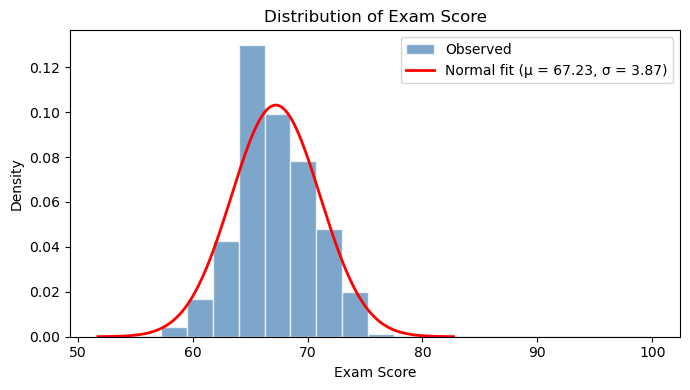

In [166]:
mu = df["Exam_Score"].mean()
sig = df["Exam_Score"].std()
x = np.linspace(mu - 4*sig, mu + 4*sig, 300)
pdf = (1 / (sig * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sig) ** 2)

fig, ax = subplots(figsize=(7, 4))
ax.hist(df["Exam_Score"], bins=20, density=True,
        color="steelblue", alpha=0.7, edgecolor="white", label="Observed")
ax.plot(x, pdf, "r-", linewidth=2,
        label=f"Normal fit (μ = {mu:.2f}, σ = {sig:.2f})")
ax.set_title("Distribution of Exam Score")
ax.set_xlabel("Exam Score")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()

In [167]:
desc_stats = df.describe().T[["mean", "std", "min", "50%", "max"]]
desc_stats["CV"] = df.std(numeric_only=True) / df.mean(numeric_only=True)
desc_stats["Skewness"] = df.skew(numeric_only=True)

desc_stats.columns = ["Mean", "Std Dev", "Min", "Median", "Max", "CV", "Skewness"]

desc_stats = desc_stats.round({
    "Mean": 2, "Std Dev": 2, "Min": 0, "Median": 1, "Max": 0,
    "CV": 3, "Skewness": 2
})

display(desc_stats.sort_values(by="CV", ascending=False))

,Mean,Std Dev,Min,Median,Max,CV,Skewness
Variable,,,,,,,
Tutoring_Sessions,1.49,1.23,0.0,1.0,8.0,0.824,0.81
Physical_Activity,2.97,1.03,0.0,3.0,6.0,0.348,-0.03
Hours_Studied,19.97,5.99,1.0,20.0,44.0,0.300,0.01
Sleep_Hours,7.03,1.47,4.0,7.0,10.0,0.209,-0.02
Previous_Scores,75.07,14.40,50.0,75.0,100.0,0.192,-0.00
Attendance,79.97,11.55,60.0,80.0,100.0,0.144,0.01
Exam_Score,67.23,3.87,55.0,67.0,100.0,0.058,1.58


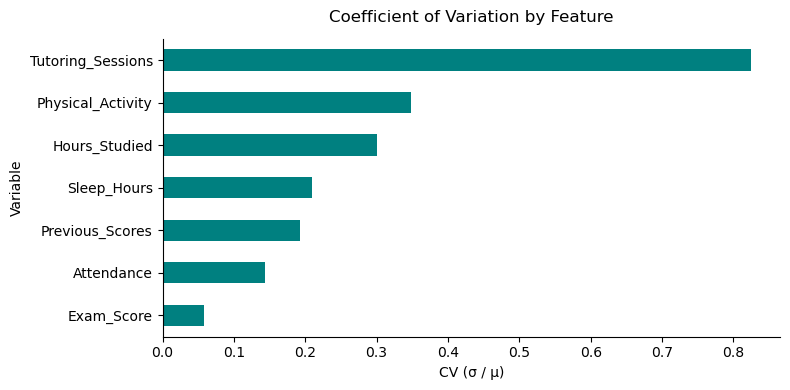

In [168]:
fig, ax = subplots(figsize=(8, 4))
desc_stats["CV"].sort_values().plot(kind="barh", color="teal", ax=ax)

ax.set_title("Coefficient of Variation by Feature", fontsize=12, pad=12)
ax.set_xlabel("CV (σ / μ)")
ax.set_ylabel("Variable")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()

`Exam_Score` is approximately normally distributed across its central range but exhibits a positive right-skew (skewness = 1.64), driven by a sparse tail of high-scoring students. Accordingly, the mean (μ = 67.24) lies just above the median (67.0), whilst the bulk of students score between 60 and 75.

The Coefficient of Variation (CV = σ/μ) provides a scale-free measure of relative dispersion across predictors. Behavioural features — `Tutoring_Sessions` (CV = 0.824) and `Physical_Activity` (CV = 0.347) — exhibit the greatest relative variability, reflecting marked heterogeneity in student habits. Academic metrics such as `Attendance` (CV = 0.144) are considerably more stable. This contrast suggests that behavioural variables may offer stronger discriminatory power in modelling than more homogeneous academic measures.

### 1.4 Correlation with Target

Pearson correlations between each numerical predictor and `Exam_Score`, computed separately for Track A and Track B.

In [169]:
corr_A = df.corr(numeric_only=True)["Exam_Score"]
corr_B = df_dropped.corr(numeric_only=True)["Exam_Score"]

corr_comp = pd.concat([
    corr_A.rename("Track A (Imputed)"),
    corr_B.rename("Track B (Dropped)")
], axis=1)
corr_comp['Difference'] = (corr_comp.iloc[:, 1] - corr_comp.iloc[:, 0])

display(corr_comp.sort_values(by="Track A (Imputed)").round(3))

,Track A (Imputed),Track B (Dropped),Difference
Variable,,,
Sleep_Hours,-0.016,-0.016,-0.000
Physical_Activity,0.028,0.025,-0.003
Tutoring_Sessions,0.154,0.154,0.000
Previous_Scores,0.174,0.174,-0.001
Hours_Studied,0.447,0.446,-0.000
Attendance,0.582,0.582,-0.001
Exam_Score,1.000,1.000,0.000


`Attendance` (~0.58) and `Hours_Studied` (~0.45) are the strongest predictors in both tracks. `Sleep_Hours` and `Physical_Activity` are near zero. Correlation coefficients are nearly identical across tracks, confirming that the small number of dropped rows has negligible impact on the linear signal.

## 2. Data Preprocessing

Both tracks undergo the same pipeline: 80/20 train–test split (`random_state = 42`), missing-value treatment, and one-hot encoding of categorical variables. The response variable is defined below; all preprocessing is applied to each track independently to prevent any cross-contamination of information.

In [170]:
TARGET = "Exam_Score"

### 2.1 Track A — Mode Imputation

The full 6,606-row dataset (NaNs retained) is split 80/20 before any imputation. The mode of each missing categorical column is computed on the training partition only and then applied to the test set, preventing leakage of test-set information into the imputation step. One-hot encoding follows with `drop_first = True` to avoid perfect multicollinearity; the encoded columns are subsequently aligned between train and test to handle any unseen categories in the test fold.

In [171]:
X_a = df_imputed.drop(TARGET, axis=1)
y_a = df_imputed[TARGET]

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_a, y_a, test_size=0.2, random_state=42
)

# Mode Imputation (Loop Method; prevents data leakage)
cat_missing = ["Parental_Education_Level", "Teacher_Quality", "Distance_from_Home"]

for col in cat_missing:
    mode_value = X_train_a[col].mode()[0]
    X_train_a[col] = X_train_a[col].fillna(mode_value)
    X_test_a[col] = X_test_a[col].fillna(mode_value)

# Categorical Encoding
X_train_a_enc = pd.get_dummies(X_train_a, drop_first=True)
X_test_a_enc = pd.get_dummies(X_test_a, drop_first=True)

# Align train and test so they have the same columns
X_train_a_enc, X_test_a_enc = X_train_a_enc.align(X_test_a_enc, join="left", axis=1, fill_value=0)

### 2.2 Track B — Listwise Deletion

The 6,377 complete-case rows are split 80/20 and one-hot encoded identically to Track A. No imputation is required; column alignment is applied for consistency.

In [172]:
X_b = df_dropped.drop(TARGET, axis=1)
y_b = df_dropped[TARGET]

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_b, y_b, test_size=0.2, random_state=42
)

# Categorical Encoding
X_train_b_enc = pd.get_dummies(X_train_b, drop_first=True)
X_test_b_enc = pd.get_dummies(X_test_b, drop_first=True)

# Align to ensure consistent columns across train and test
X_train_b_enc, X_test_b_enc = X_train_b_enc.align(X_test_b_enc, join="left", axis=1, fill_value=0)

### 2.3 Full-Dataset Construction

The training and test partitions are recombined for each track to facilitate 10-fold cross-validation, providing a more statistically stable estimate of model performance than a single hold-out split.

For Track A, imputation parameters (modes) were strictly derived from the initial 80% training partition and then broadcast to the remaining observations. This methodology prevents data leakage by ensuring that information from the test set does not influence the training process. Given that categorical modes are highly stable in large samples, the impact of using fixed imputation parameters on the cross-validation variance is expected to be negligible.

The table below summarises the structural consistency of the experimental tracks, confirming that despite the difference in sample size ($N$), both maintain an identical high-dimensional feature space ($p = 27$).

In [173]:
# Recombine partitions for cross-validation
X_full_a_enc = pd.concat([X_train_a_enc, X_test_a_enc]).reset_index(drop=True)
y_full_a = pd.concat([y_train_a, y_test_a]).reset_index(drop=True)

X_full_b_enc = pd.concat([X_train_b_enc, X_test_b_enc]).reset_index(drop=True)
y_full_b = pd.concat([y_train_b, y_test_b]).reset_index(drop=True)

# Create the expanded comparison table
comparison_summary = pd.DataFrame({
    "Track A": [
        X_train_a_enc.shape[0], 
        X_test_a_enc.shape[0], 
        X_full_a_enc.shape[0], 
        X_full_a_enc.shape[1]
    ],
    "Track B": [
        X_train_b_enc.shape[0], 
        X_test_b_enc.shape[0], 
        X_full_b_enc.shape[0], 
        X_full_b_enc.shape[1]
    ]
}, index=["Training observations", "Test observations", "Full observations", "Encoded features"])

comparison_summary.index.name = "Dataset Metric"
display(comparison_summary)

# Verification check
print(f"Feature names match: {list(X_full_a_enc.columns) == list(X_full_b_enc.columns)}")

,Track A,Track B
Dataset Metric,,
Training observations,5284,5101
Test observations,1322,1276
Full observations,6606,6377
Encoded features,27,27


Feature names match: True


## 3. Global Regression Models

### 3.1 Null Model (Intercept-only Baseline)

A null model (intercept-only) predicts the training-set mean for every observation, $\hat{Y}_i = \bar{Y}_{\text{train}}$.  This is the simplest possible model and establishes a performance floor: any model that cannot beat this RMSE offers no useful predictive signal.


In [174]:
cv = KFold(n_splits=10, shuffle=True, random_state=42)

# --- Track A ---
cv_null_a = cross_validate(
    DummyRegressor(strategy="mean"),
    X_full_a_enc, y_full_a, cv=cv, scoring="neg_root_mean_squared_error"
)
rmse_cv_null_a = -cv_null_a["test_score"].mean()
std_cv_null_a = cv_null_a["test_score"].std()

# --- Track B ---
cv_null_b = cross_validate(
    DummyRegressor(strategy="mean"),
    X_full_b_enc, y_full_b, cv=cv, scoring="neg_root_mean_squared_error"
)
rmse_cv_null_b = -cv_null_b["test_score"].mean()
std_cv_null_b = cv_null_b["test_score"].std()

print(f"Null Model — Track A:  CV RMSE = {rmse_cv_null_a:.3f}  (s.d. {std_cv_null_a:.3f})")
print(f"Null Model — Track B:  CV RMSE = {rmse_cv_null_b:.3f}  (s.d. {std_cv_null_b:.3f})")

Null Model — Track A:  CV RMSE = 3.859  (s.d. 0.278)
Null Model — Track B:  CV RMSE = 3.883  (s.d. 0.260)


The null model CV RMSE (Track A: 3.859, Track B: 3.883) is approximately equal to the marginal standard deviation of `Exam_Score` — the expected result, since predicting the training mean produces residuals identical to the deviations from the mean. Any model that fails to reduce RMSE below this threshold has no predictive utility and yields a non-positive $R^2$.

### 3.2 Multiple Linear Regression

A multiple linear regression model is fitted to both tracks to assess whether the missing-data handling strategy materially affects predictive performance.

In [175]:
cv = KFold(n_splits=10, shuffle=True, random_state=42)

# --- Track A ---
lr_a = LinearRegression()
lr_a.fit(X_train_a_enc, y_train_a)

pred_train_a = lr_a.predict(X_train_a_enc)
pred_test_a = lr_a.predict(X_test_a_enc)
rmse_train_a = np.sqrt(mean_squared_error(y_train_a, pred_train_a))
rmse_test_a  = np.sqrt(mean_squared_error(y_test_a,  pred_test_a))

cv_lr_a = cross_validate(lr_a, X_full_a_enc, y_full_a,
                           cv=cv, scoring="neg_root_mean_squared_error")
rmse_cv_a = -cv_lr_a["test_score"].mean()
std_cv_a = cv_lr_a["test_score"].std()

# --- Track B ---
lr_b = LinearRegression()
lr_b.fit(X_train_b_enc, y_train_b)

pred_train_b = lr_b.predict(X_train_b_enc)
pred_test_b = lr_b.predict(X_test_b_enc)
rmse_train_b = np.sqrt(mean_squared_error(y_train_b, pred_train_b))
rmse_test_b  = np.sqrt(mean_squared_error(y_test_b,  pred_test_b))

cv_lr_b = cross_validate(lr_b, X_full_b_enc, y_full_b,
                           cv=cv, scoring="neg_root_mean_squared_error")
rmse_cv_b = -cv_lr_b["test_score"].mean()
std_cv_b = cv_lr_b["test_score"].std()

print(f"Track A — Training RMSE: {rmse_train_a:.3f}")
print(f"Track A — Hold-out RMSE: {rmse_test_a:.3f}")
print(f"Track A — CV RMSE:       {rmse_cv_a:.3f}  (s.d. {std_cv_a:.3f})")
print()
print(f"Track B — Training RMSE: {rmse_train_b:.3f}")
print(f"Track B — Hold-out RMSE: {rmse_test_b:.3f}")
print(f"Track B — CV RMSE:       {rmse_cv_b:.3f}  (s.d. {std_cv_b:.3f})")

Track A — Training RMSE: 2.109
Track A — Hold-out RMSE: 1.521
Track A — CV RMSE:       1.968  (s.d. 0.425)

Track B — Training RMSE: 2.039
Track B — Hold-out RMSE: 2.041
Track B — CV RMSE:       1.960  (s.d. 0.594)


Track B shows near-identical training and hold-out RMSE (2.039 vs 2.041), indicating no overfitting. For Track A, the hold-out RMSE (1.521) falls below the training RMSE (2.109) — an atypical result caused by the 80/20 split yielding a test partition with lower inherent variability; the 10-fold CV RMSE is the more reliable generalisation estimate.

The two tracks produce near-identical CV RMSEs (Track A: 1.968, Track B: 1.960), indicating that the choice of missing-data strategy has negligible impact on predictive accuracy for linear regression. Track A exhibits smaller fold-to-fold variation (CV s.d. 0.425 vs 0.594), suggesting slightly more stable generalisation across resamples. Both models comfortably surpass the null model benchmark (CV RMSE ≈ 3.87), confirming that the predictors carry substantial explanatory power.

#### 3.2.3 Residual Diagnostics

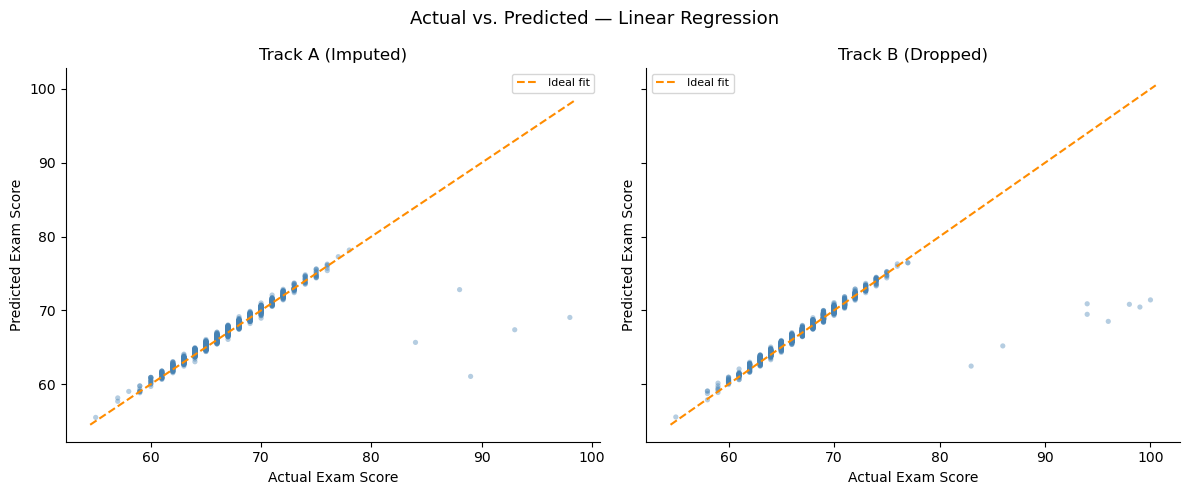

In [176]:
fig, axes = subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, y_test, pred, title in zip(
    axes,
    [y_test_a, y_test_b],
    [pred_test_a, pred_test_b],
    ["Track A (Imputed)", "Track B (Dropped)"],
):
    ax.scatter(y_test, pred, color="steelblue", alpha=0.4, s=14, edgecolors="none")
    lo = min(y_test.min(), pred.min()) - 0.5
    hi = max(y_test.max(), pred.max()) + 0.5
    ax.plot([lo, hi], [lo, hi], "--", color="darkorange", linewidth=1.5, label="Ideal fit")
    ax.set_xlabel("Actual Exam Score")
    ax.set_ylabel("Predicted Exam Score")
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("Actual vs. Predicted — Linear Regression", fontsize=13)
plt.tight_layout()

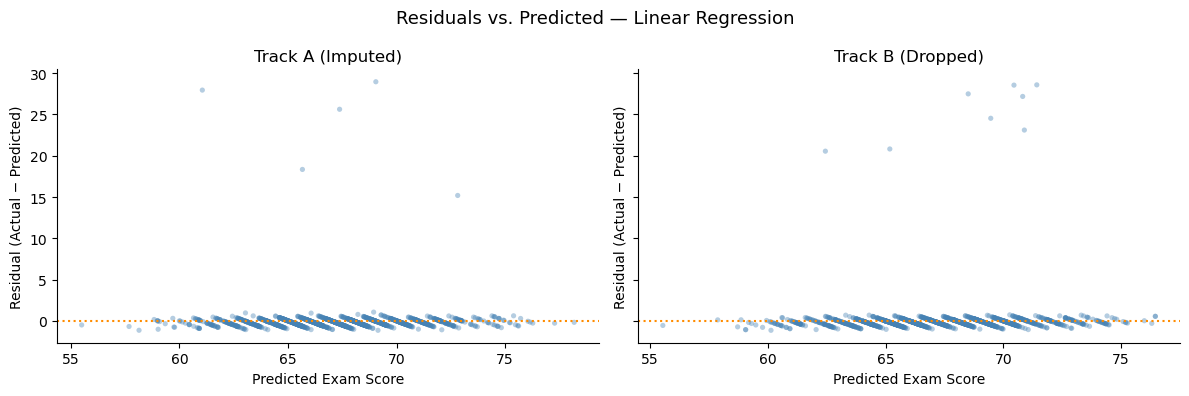

In [177]:
fig, axes = subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, pred, y_test, title in zip(
    axes,
    [pred_test_a, pred_test_b],
    [y_test_a, y_test_b],
    ["Track A (Imputed)", "Track B (Dropped)"],
):
    resid = y_test.values - pred
    ax.scatter(pred, resid, color="steelblue", alpha=0.4, s=14, edgecolors="none")
    ax.axhline(0, linestyle=":", color="darkorange", linewidth=1.5)
    ax.set_xlabel("Predicted Exam Score")
    ax.set_ylabel("Residual (Actual − Predicted)")
    ax.set_title(title, fontsize=12)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("Residuals vs. Predicted — Linear Regression", fontsize=13)
plt.tight_layout()

Across the mid-range of predicted values, residuals scatter randomly around zero in both tracks, suggesting that the linear specification satisfies the Gauss-Markov assumptions for most students. However, a distinct cluster of large positive residuals (Actual $\gg$ Predicted) appears at the higher score ranges. This systematic underprediction is clearly visible in the Actual vs. Predicted plots, where top-performing students deviate significantly from the $45^{\circ}$ line.

This upper-tail bias indicates that elite academic performance (specifically scores exceeding 85) is not fully captured by a linear additive framework. The observed error pattern suggests the presence of complex non-linear interactions or latent variables that a standard regression approach cannot isolate. Consequently, we move to Tree-based models in Section 4 to determine if recursive partitioning can better accommodate these non-linearities and capture the nuances of high-performing outliers.

## 4. Tree-based Models


### 4.1 Decision Tree Regressor

Decision trees partition the feature space through recursive binary splits. The key tuning parameter is depth: too shallow and the model underfits; too deep and it memorises the training data. We begin by selecting the optimal depth through systematic cross-validation, then evaluate three canonical configurations — depth = 3 (underfitting baseline), optimally pruned, and unconstrained (overfitting extreme) — to span the full bias–variance spectrum.

#### 4.1.1 Selecting Optimal Tree Depth

Next, we scan depths 1–20 and choose the depth that minimises 10-fold CV RMSE on both tracks. The linear regression CV RMSE is superimposed as a performance reference.

In [178]:
cv = KFold(n_splits=10, shuffle=True, random_state=42)
depths = list(range(1, 21))

rmse_depth_a, std_depth_a = [], []
rmse_depth_b, std_depth_b = [], []

for d in depths:
    # Track A
    res_a = cross_validate(
        DecisionTreeRegressor(max_depth=d, random_state=42),
        X_full_a_enc, y_full_a, cv=cv, scoring="neg_root_mean_squared_error"
    )
    rmse_depth_a.append(-res_a["test_score"].mean())
    std_depth_a.append(res_a["test_score"].std())

    # Track B
    res_b = cross_validate(
        DecisionTreeRegressor(max_depth=d, random_state=42),
        X_full_b_enc, y_full_b, cv=cv, scoring="neg_root_mean_squared_error"
    )
    rmse_depth_b.append(-res_b["test_score"].mean())
    std_depth_b.append(res_b["test_score"].std())

rmse_depth_a = np.array(rmse_depth_a)
rmse_depth_b = np.array(rmse_depth_b)
std_depth_a = np.array(std_depth_a)
std_depth_b = np.array(std_depth_b)

opt_depth_a = depths[int(np.argmin(rmse_depth_a))]
opt_depth_b = depths[int(np.argmin(rmse_depth_b))]


# Extract CV metrics at depth=3 and optimal depths directly from scan arrays
rmse_cv_a_tree3 = float(rmse_depth_a[2])
std_cv_a_tree3 = float(std_depth_a[2])
rmse_cv_b_tree3 = float(rmse_depth_b[2])
std_cv_b_tree3 = float(std_depth_b[2])

rmse_cv_a_tree_opt = float(rmse_depth_a[opt_depth_a - 1])
std_cv_a_tree_opt = float(std_depth_a[opt_depth_a - 1])
rmse_cv_b_tree_opt = float(rmse_depth_b[opt_depth_b - 1])
std_cv_b_tree_opt = float(std_depth_b[opt_depth_b - 1])


print(f"Track A — optimal depth: {opt_depth_a}  "
      f"(CV RMSE = {rmse_cv_a_tree_opt:.3f}, s.d. {std_cv_a_tree_opt:.3f})")
print(f"Track B — optimal depth: {opt_depth_b}  "
      f"(CV RMSE = {rmse_cv_b_tree_opt:.3f}, s.d. {std_cv_b_tree_opt:.3f})")

Track A — optimal depth: 6  (CV RMSE = 2.666, s.d. 0.355)
Track B — optimal depth: 5  (CV RMSE = 2.703, s.d. 0.406)


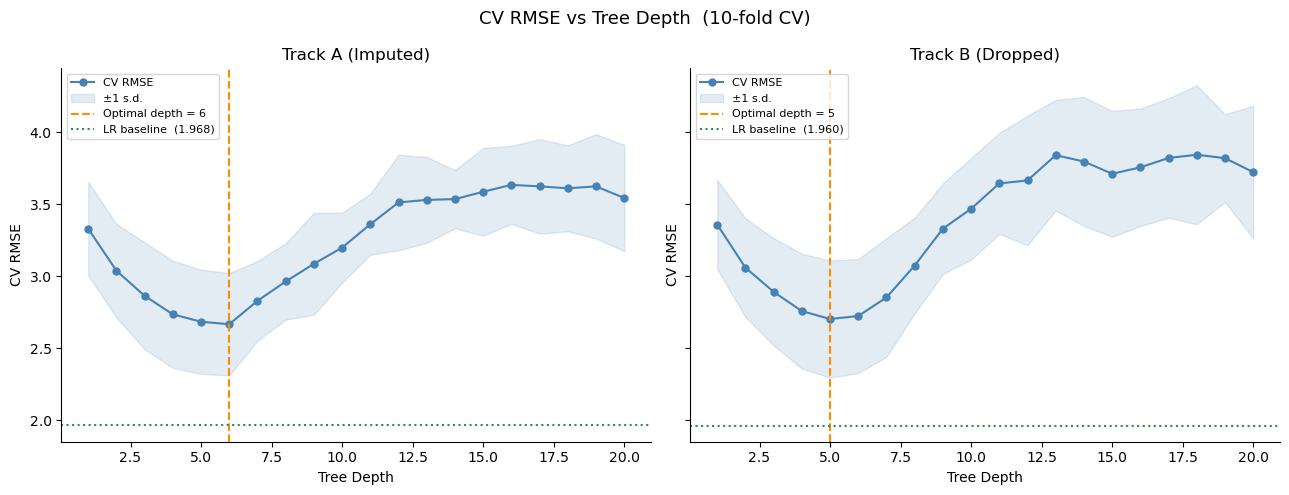

In [179]:
fig, axes = subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, rmse_arr, std_arr, opt_d, rmse_lr, label in zip(
    axes,
    [rmse_depth_a, rmse_depth_b],
    [std_depth_a, std_depth_b],
    [opt_depth_a, opt_depth_b],
    [rmse_cv_a, rmse_cv_b],
    ["Track A (Imputed)", "Track B (Dropped)"],
):
    ax.plot(depths, rmse_arr, "o-", color="steelblue", markersize=5, label="CV RMSE")
    ax.fill_between(depths, rmse_arr - std_arr, rmse_arr + std_arr,
                    alpha=0.15, color="steelblue", label="±1 s.d.")
    ax.axvline(opt_d, linestyle="--", color="darkorange",
               label=f"Optimal depth = {opt_d}")
    ax.axhline(rmse_lr, linestyle=":", color="seagreen", linewidth=1.5,
               label=f"LR baseline  ({rmse_lr:.3f})")
    ax.set_title(label, fontsize=12)
    ax.set_xlabel("Tree Depth")
    ax.set_ylabel("CV RMSE")
    ax.legend(fontsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("CV RMSE vs Tree Depth  (10-fold CV)", fontsize=13)
plt.tight_layout()

CV RMSE decreases sharply from depth 1 (severe underfitting) before reaching a minimum and rising again as variance dominates. Track A achieves its minimum at depth 6 (CV RMSE = 2.666, s.d. = 0.355); Track B at depth 5 (CV RMSE = 2.703, s.d. = 0.406). The near-identical optimal depths confirm that the missing-data strategy has negligible influence on model selection.

Crucially, neither track approaches the linear regression baseline (CV RMSE ≈ 1.97) even at the optimal depth, reinforcing that the dominant signal in this dataset is approximately linear — consistent with the strong Pearson correlations in Section 1.4.

#### 4.1.2 Canonical Tree Configurations

We now fit three representative trees on both tracks: depth = 3 (underfitting baseline), the track-specific optimal depth (6 for A, 5 for B), and unconstrained. Hold-out RMSE and 10-fold CV RMSE are reported; CV metrics at depth = 3 and optimal depth are extracted directly from the depth-scan arrays above.

In [180]:
# --- Depth = 3 ---
tree_a_depth3 = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_a_depth3.fit(X_train_a_enc, y_train_a)
rmse_train_a_tree3 = np.sqrt(mean_squared_error(y_train_a, tree_a_depth3.predict(X_train_a_enc)))
rmse_test_a_tree3 = np.sqrt(mean_squared_error(y_test_a, tree_a_depth3.predict(X_test_a_enc)))

tree_b_depth3 = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_b_depth3.fit(X_train_b_enc, y_train_b)
rmse_train_b_tree3 = np.sqrt(mean_squared_error(y_train_b, tree_b_depth3.predict(X_train_b_enc)))
rmse_test_b_tree3 = np.sqrt(mean_squared_error(y_test_b, tree_b_depth3.predict(X_test_b_enc)))


# --- Optimal depth ---
tree_a_opt = DecisionTreeRegressor(max_depth=opt_depth_a, random_state=42)
tree_a_opt.fit(X_train_a_enc, y_train_a)
rmse_train_a_opt = np.sqrt(mean_squared_error(y_train_a, tree_a_opt.predict(X_train_a_enc)))
rmse_test_a_opt = np.sqrt(mean_squared_error(y_test_a, tree_a_opt.predict(X_test_a_enc)))

tree_b_opt = DecisionTreeRegressor(max_depth=opt_depth_b, random_state=42)
tree_b_opt.fit(X_train_b_enc, y_train_b)
rmse_train_b_opt = np.sqrt(mean_squared_error(y_train_b, tree_b_opt.predict(X_train_b_enc)))
rmse_test_b_opt = np.sqrt(mean_squared_error(y_test_b, tree_b_opt.predict(X_test_b_enc)))


# --- Unconstrained (hold-out + CV; fully grown trees exceed depth-20 scan) ---
tree_a_full = DecisionTreeRegressor(random_state=42)
tree_a_full.fit(X_train_a_enc, y_train_a)
rmse_train_a_full = np.sqrt(mean_squared_error(y_train_a, tree_a_full.predict(X_train_a_enc)))
rmse_test_a_full = np.sqrt(mean_squared_error(y_test_a, tree_a_full.predict(X_test_a_enc)))

tree_b_full = DecisionTreeRegressor(random_state=42)
tree_b_full.fit(X_train_b_enc, y_train_b)
rmse_train_b_full = np.sqrt(mean_squared_error(y_train_b, tree_b_full.predict(X_train_b_enc)))
rmse_test_b_full = np.sqrt(mean_squared_error(y_test_b, tree_b_full.predict(X_test_b_enc)))

cv = KFold(n_splits=10, shuffle=True, random_state=42)
cv_a_full = cross_validate(DecisionTreeRegressor(random_state=42),
                           X_full_a_enc, y_full_a, cv=cv,
                           scoring="neg_root_mean_squared_error")
rmse_cv_a_full = -cv_a_full["test_score"].mean()
std_cv_a_full = cv_a_full["test_score"].std()

cv_b_full = cross_validate(DecisionTreeRegressor(random_state=42),
                           X_full_b_enc, y_full_b, cv=cv,
                           scoring="neg_root_mean_squared_error")
rmse_cv_b_full = -cv_b_full["test_score"].mean()
std_cv_b_full = cv_b_full["test_score"].std()


# Summary table
summary = pd.DataFrame({
    "Configuration": [
        "Depth = 3",
        f"Depth = {opt_depth_a} / {opt_depth_b}  (optimal, A / B)",
        "Unconstrained",
    ],
    "A: Train": [rmse_train_a_tree3, rmse_train_a_opt, rmse_train_a_full],
    "A: Test": [rmse_test_a_tree3, rmse_test_a_opt, rmse_test_a_full],
    "A: CV RMSE": [rmse_cv_a_tree3, rmse_cv_a_tree_opt, rmse_cv_a_full],
    "A: CV s.d.": [std_cv_a_tree3, std_cv_a_tree_opt, std_cv_a_full],
    "B: Train": [rmse_train_b_tree3, rmse_train_b_opt, rmse_train_b_full],
    "B: Test": [rmse_test_b_tree3, rmse_test_b_opt, rmse_test_b_full],
    "B: CV RMSE": [rmse_cv_b_tree3, rmse_cv_b_tree_opt, rmse_cv_b_full],
    "B: CV s.d.": [std_cv_b_tree3, std_cv_b_tree_opt, std_cv_b_full],
})

(summary.style
    .format(precision=3)
    .highlight_min(subset=["A: CV RMSE", "B: CV RMSE"], color="lightgreen")
    .highlight_max(subset=["A: CV RMSE", "B: CV RMSE"], color="#ffcccc"))

,Configuration,A: Train,A: Test,A: CV RMSE,A: CV s.d.,B: Train,B: Test,B: CV RMSE,B: CV s.d.
0,Depth = 3,2.923,2.564,2.863,0.371,2.862,3.007,2.891,0.372
1,"Depth = 6 / 5 (optimal, A / B)",2.525,2.496,2.666,0.355,2.601,2.927,2.703,0.406
2,Unconstrained,0.000,3.674,3.497,0.302,0.000,3.653,3.714,0.409


Depth = 3 avoids gross overfitting (training and test RMSE are broadly aligned) but underfits relative to both the optimal tree and linear regression. The optimal-depth trees improve CV RMSE meaningfully over depth = 3 whilst keeping train–test spread modest. The unconstrained tree achieves zero training RMSE (perfect memorisation) but the highest test and CV RMSE of the three configurations (highlighted red), exemplifying the high-variance extreme of the bias–variance trade-off.

#### 4.1.3 All-Depth Comparison

The grouped bar chart below compares 10-fold CV RMSE across the four depth configurations evaluated in this section, with ±1 s.d. error bars and per-track LR baselines. The star (★) marks the track-optimal depth.

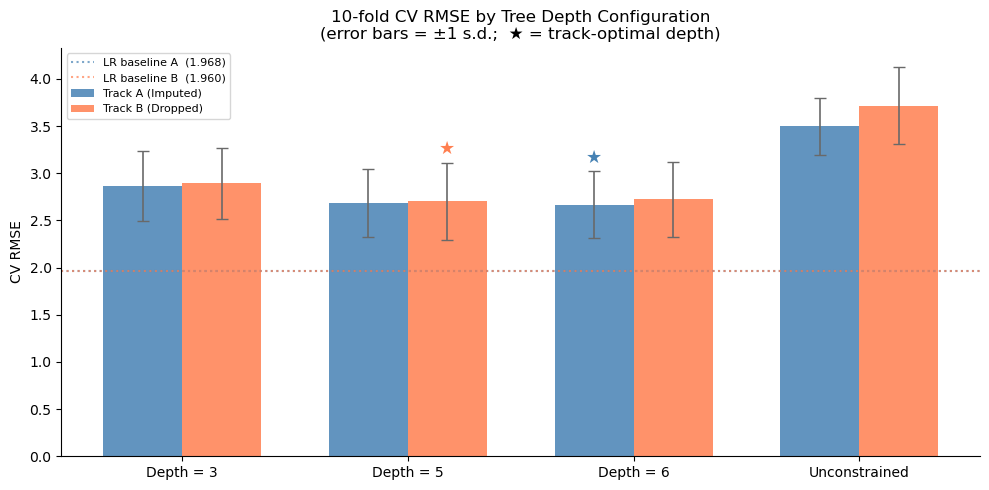

In [181]:
labels = ["Depth = 3", "Depth = 5", "Depth = 6", "Unconstrained"]

a_rmse = [rmse_cv_a_tree3, float(rmse_depth_a[4]), float(rmse_depth_a[5]), rmse_cv_a_full]
a_std = [std_cv_a_tree3, float(std_depth_a[4]), float(std_depth_a[5]), std_cv_a_full]
b_rmse = [rmse_cv_b_tree3, float(rmse_depth_b[4]), float(rmse_depth_b[5]), rmse_cv_b_full]
b_std = [std_cv_b_tree3, float(std_depth_b[4]), float(std_depth_b[5]), std_cv_b_full]

x = np.arange(len(labels))
width = 0.35

fig, ax = subplots(figsize=(10, 5))
ax.bar(x - width/2, a_rmse, width, yerr=a_std, capsize=4,
       color="steelblue", alpha=0.85, label="Track A (Imputed)",
       error_kw={"elinewidth": 1.2, "ecolor": "dimgrey"})
ax.bar(x + width/2, b_rmse, width, yerr=b_std, capsize=4,
       color="coral", alpha=0.85, label="Track B (Dropped)",
       error_kw={"elinewidth": 1.2, "ecolor": "dimgrey"})

# Mark optimal depths with a star
opt_a_idx = labels.index(f"Depth = {opt_depth_a}")
opt_b_idx = labels.index(f"Depth = {opt_depth_b}")
ax.text(x[opt_a_idx] - width/2, a_rmse[opt_a_idx] + a_std[opt_a_idx] + 0.05,
        "★", ha="center", va="bottom", color="steelblue", fontsize=13)
ax.text(x[opt_b_idx] + width/2, b_rmse[opt_b_idx] + b_std[opt_b_idx] + 0.05,
        "★", ha="center", va="bottom", color="coral", fontsize=13)

# LR baselines
ax.axhline(rmse_cv_a, linestyle=":", color="steelblue", linewidth=1.5, alpha=0.7,
           label=f"LR baseline A  ({rmse_cv_a:.3f})")
ax.axhline(rmse_cv_b, linestyle=":", color="coral", linewidth=1.5, alpha=0.7,
           label=f"LR baseline B  ({rmse_cv_b:.3f})")

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("CV RMSE")
ax.set_title(
    "10-fold CV RMSE by Tree Depth Configuration\n"
    "(error bars = ±1 s.d.;  ★ = track-optimal depth)",
    fontsize=12,
)
ax.legend(fontsize=8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()

The chart confirms the bias–variance progression: CV RMSE is elevated at depth = 3 (underfitting) and peaks for the unconstrained tree (overfitting), with the minimum at the track-optimal depth (★). At depth 5 Track B is already at its optimum, whilst Track A still benefits from one additional split (depth 6). The LR baselines (dotted lines) remain well below all tree configurations at every depth, quantifying the residual performance gap that depth selection alone cannot close.

## 5. Model Comparison

### Model Comparison Table

In [182]:
comparison_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree  (depth = 3)",
        f"Decision Tree  (depth = {opt_depth_a} / {opt_depth_b}, optimal)",
        "Decision Tree  (unconstrained)",
    ],
    "Track A: CV RMSE": [rmse_cv_a, rmse_cv_a_tree3, rmse_cv_a_tree_opt, rmse_cv_a_full],
    "Track A: CV Std": [std_cv_a, std_cv_a_tree3, std_cv_a_tree_opt, std_cv_a_full],
    "Track B: CV RMSE": [rmse_cv_b, rmse_cv_b_tree3, rmse_cv_b_tree_opt, rmse_cv_b_full],
    "Track B: CV Std": [std_cv_b, std_cv_b_tree3, std_cv_b_tree_opt, std_cv_b_full],
})

(comparison_df.style
    .format({
        "Track A: CV RMSE": "{:.3f}",
        "Track A: CV Std":  "{:.3f}",
        "Track B: CV RMSE": "{:.3f}",
        "Track B: CV Std":  "{:.3f}",
    })
    .highlight_min(subset=["Track A: CV RMSE", "Track B: CV RMSE"], color="lightgreen")
    .highlight_max(subset=["Track A: CV RMSE", "Track B: CV RMSE"], color="#ffcccc"))

,Model,Track A: CV RMSE,Track A: CV Std,Track B: CV RMSE,Track B: CV Std
0,Linear Regression,1.968,0.425,1.960,0.594
1,Decision Tree (depth = 3),2.863,0.371,2.891,0.372
2,"Decision Tree (depth = 6 / 5, optimal)",2.666,0.355,2.703,0.406
3,Decision Tree (unconstrained),3.497,0.302,3.714,0.409


Linear regression achieves the lowest CV RMSE in both tracks (A: 1.968, B: 1.960), confirming it as the best-performing model for this dataset. Among tree configurations, the optimally pruned tree provides the strongest generalisation, yet still falls short of linear regression by approximately 0.70 RMSE units — reinforcing that the dominant signal is approximately linear.

The depth-3 tree underfits relative to the optimal, offering a simpler and more interpretable model at the cost of predictive accuracy. The unconstrained tree occupies the opposite extreme: zero training RMSE but the worst CV RMSE, illustrating the high-variance regime.

For tree-based models, Track A consistently achieves lower CV RMSE than Track B, confirming that mode imputation preserves more predictive signal than listwise deletion. For linear regression the two tracks are essentially tied, suggesting that the imputation choice has a greater impact on the non-linear models that are more sensitive to local data structure.